## Mission 4: Predicting House Price with Multiple Linear Regression

Introduction
In this mission, you will be working with a real estate dataset to perform Exploratory Data Analysis (EDA) and create a Multiple Linear Regression (MLR) model to predict the Price of a house based on various features such as Square Feet, Number of Bedrooms, Number of Bathrooms, and other factors.

The dataset includes the following columns:

**Square_Feet:** The total area of the house in square feet.

**Num_Bedrooms:** The number of bedrooms in the house.

**Num_Bathrooms:** The number of bathrooms in the house.

**Num_Floors:** The number of floors in the house.

**Garage_Size:** The size of the garage.

**Location_Score:** A score representing the desirability of the location.

**Distance_to_Center:** The distance (in km) to the city center.

**Price:** The price of the house (target variable).


## Step 1: Loading and Understanding the Data

Start by loading the dataset into a Pandas DataFrame. Inspect the first few rows of the dataset and understand its structure.

Tasks:

Task 1.1. The data is stored in Azure Blob Storage. To connect to Azure Blob Storage, we will use a connection string that contains authentication details such as the account name and account key. See the credentials below.


Task 1.2. Load the dataset into a Pandas DataFrame from the CSV file stored in Blob Storage. Name the dataframe as df_house_price

Task 1.3. Display the first few rows.

Task 1.4. Check the data types and null values.

In [ ]:
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=YOUR_AZURE_KEY_HERE;EndpointSuffix=core.windows.net"
container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

In [ ]:
import pandas as pd
from azure.storage.blob import BlobServiceClient
from io import StringIO

# Azure Blob Storage connection details
connect_str = "DefaultEndpointsProtocol=https;AccountName=level5data;AccountKey=YOUR_AZURE_KEY_HERE;EndpointSuffix=core.windows.net"

container_name = "businesscases"
blob_name = "house_sales_prediction.csv"

# Create a BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(connect_str)

# Get the container client
container_client = blob_service_client.get_container_client(container_name)

# Get the blob client
blob_client = container_client.get_blob_client(blob_name)

# Download the blob
blob_data = blob_client.download_blob()
csv_content = blob_data.readall().decode('utf-8')

# Load data into a Pandas DataFrame
df_house_price = pd.read_csv(StringIO(csv_content))

# Display the first few rows
display(df_house_price.head())

<mark>Data imported successfully</mark> 

In [ ]:
# Check for missing values in dataset
missing_values = df_house_price.isnull().sum()
print(f"Missing Values:\n{missing_values}")

Missing Values:
Square_Feet           0
Num_Bedrooms          0
Num_Bathrooms         0
Num_Floors            0
Garage_Size           0
Location_Score        0
Distance_to_Center    0
Price                 0
dtype: int64


<mark>No null items found</mark>

In [ ]:
# Check the data types of the columns
print(f"Data Types:\n{df_house_price.dtypes}")

Data Types:
Square_Feet           float64
Num_Bedrooms            int64
Num_Bathrooms           int64
Num_Floors              int64
Garage_Size             int64
Location_Score        float64
Distance_to_Center    float64
Price                 float64
dtype: object


<mark>All types checked</mark>

## Step 2: Exploratory Data Analysis (EDA)

In this step, you will perform some basic EDA to understand the relationships between the features and the target variable (Price). This includes visualising the data, checking for correlations, and identifying patterns.

Tasks:

Task 2.1. Check summary statistics for the dataset.

Task 2.2. Visualise the relationship between Square Feet and Price using a scatter plot.

Task 2.3.  Visualise the distribution of the Price variable using a histogram.

Task 2.4.  Compute and visualize the correlation matrix between the features.

Task 2.5. Write 1–2 sentences for each visualisation explaining the insights you gained from the chart.

In [ ]:
#Task 2.1
# Check summary statistics for the dataset
summary_stats = df_house_price.describe()
print(f"Summary Statistics:\n{summary_stats}")

Summary Statistics:
       Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Garage_Size  \
count   500.000000    500.000000     500.000000  500.000000   500.000000   
mean    174.640428      2.958000       1.976000    1.964000    30.174000   
std      74.672102      1.440968       0.820225    0.802491    11.582575   
min      51.265396      1.000000       1.000000    1.000000    10.000000   
25%     110.319923      2.000000       1.000000    1.000000    20.000000   
50%     178.290937      3.000000       2.000000    2.000000    30.000000   
75%     239.031220      4.000000       3.000000    3.000000    41.000000   
max     298.241199      5.000000       3.000000    3.000000    49.000000   

       Location_Score  Distance_to_Center          Price  
count      500.000000          500.000000     500.000000  
mean         5.164410           10.469641  582209.629531  
std          2.853489            5.588197  122273.390347  
min          0.004428            0.062818  276892.470100  


In [ ]:
##Importing seaborn matplotlib
!pip install seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 12.0 MB/s eta 0:00:00


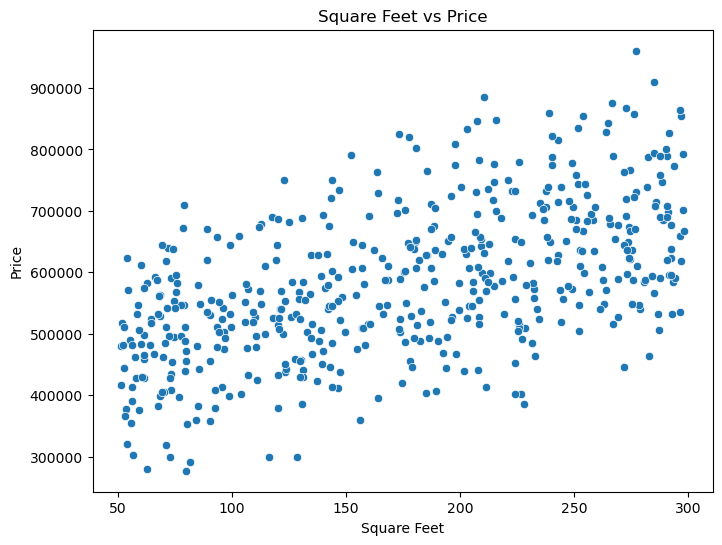

In [ ]:
#Task 2.2
# Visualise the relationship between Square Feet and Price using a scatter plot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Square_Feet', y='Price', data=df_house_price)
plt.title('Square Feet vs Price')
plt.xlabel('Square Feet')
plt.ylabel('Price')
plt.show()

<mark>This scatter plot shows a general upward trend. Larger homes tend to sell for more but the relationship is fairly noisy, with a wide spread of prices at any given square footage. This suggests square footage alone is a moderate predictor of price, and other factors (location, bedrooms, etc. ) likely contributing to the variance. </mark>

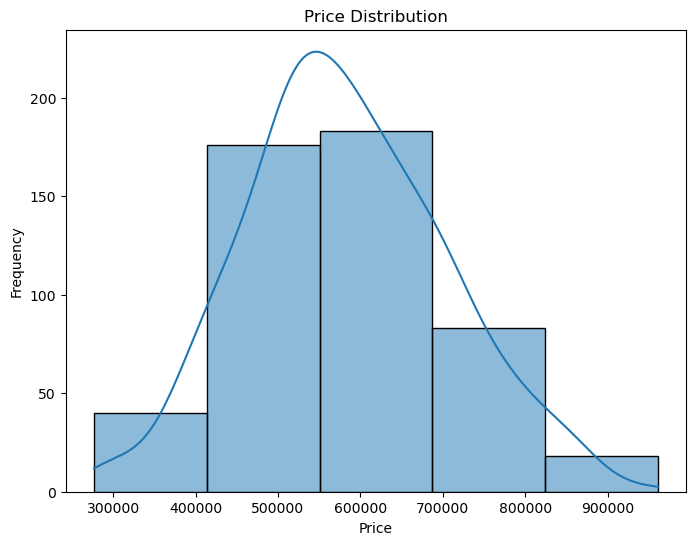

In [ ]:
# Task 2.3
# Visualise the distribution of the Price variable using a histogram

plt.figure(figsize=(8, 6))
sns.histplot(df_house_price['Price'], bins=5, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

<mark>House prices are roughly bell-shaped (normally distributed) but with a slight right skew, peaking around $500,000-$650,000. This tells you most homes in the dataset fall in the mid-price range, with fewer high-end outliers pulling the tails to the right.</mark>

Correlation Matrix:
                    Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  \
Square_Feet            1.000000     -0.049918      -0.001667    0.056873   
Num_Bedrooms          -0.049918      1.000000      -0.056808    0.009088   
Num_Bathrooms         -0.001667     -0.056808       1.000000   -0.040895   
Num_Floors             0.056873      0.009088      -0.040895    1.000000   
Garage_Size           -0.051598     -0.065481       0.055707   -0.082763   
Location_Score        -0.035270     -0.000357      -0.013855    0.019928   
Distance_to_Center     0.093080      0.040511      -0.082571    0.035164   
Price                  0.558604      0.563973       0.156689    0.177435   

                    Garage_Size  Location_Score  Distance_to_Center     Price  
Square_Feet           -0.051598       -0.035270            0.093080  0.558604  
Num_Bedrooms          -0.065481       -0.000357            0.040511  0.563973  
Num_Bathrooms          0.055707       -0.013855        

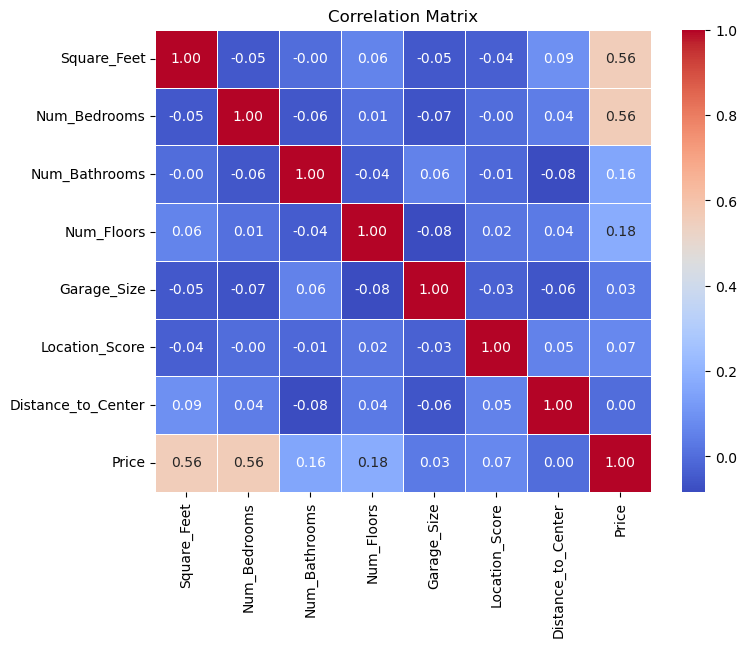

In [ ]:
# Task 2.4:

# Compute and visualize the correlation matrix between the features

correlation_matrix = df_house_price.corr()
print(f"Correlation Matrix:\n{correlation_matrix}")

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

<mark>Square_feet and Num_bedrooms have the strongest correlations with Price (0.56), while Num_Bathrooms and Num_floors show weaker positive correlations (0.16 and 0.18). Garage_size, location_Score, and Distance_to_Center show almost no correlation with Price, suggesting they may not be strong standalone predictors in a regression model.</mark>

## Step 3: Creating a Multiple Linear Regression (MLR) Model

In this step, we will use Multiple Linear Regression to predict the Price of the house based on the features. We will split the data into a training set and a testing set, fit the model, and evaluate its performance.

Task 3.1: Split the Data into Features and Target
Split the dataset into features (X) and target variable (y).

Task 3.2: Split the Data into Training and Testing Sets
Split the data into training (80%) and testing (20%) sets.

Task 3.3: Train the Multiple Linear Regression Model
Train the Multiple Linear Regression (MLR) model using the training data.

Task 3.4: Visualise the Predicted vs Actual Prices
Create a scatter plot comparing the actual prices and predicted prices for the test set.

Task 3.5: Evaluate the Model
Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

Task 3.6. Write 1–2 sentences explaining the insights from the visualisation.

In [ ]:
# Task 3.1 Split the Data into Features and Target: Features (X) and target (y)
X = df_house_price[['Square_Feet','Num_Bedrooms','Num_Bathrooms','Num_Floors','Garage_Size','Location_Score','Distance_to_Center']]
y = df_house_price['Price']

In [ ]:
# Task 3.2
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the split data
print(f"Training Data: {X_train.shape}, Testing Data: {X_test.shape}")

Training Data: (400, 7), Testing Data: (100, 7)


In [ ]:
# Task 3.3
from sklearn.linear_model import LinearRegression

# Initialize the Linear Regression model
model_lr = LinearRegression()

# Fit the model on the training data
model_lr.fit(X_train, y_train)

# Make predictions on the test data
y_pred_lr = model_lr.predict(X_test)

🏃 View run olden_endive_dx3h99x4 at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/6429dd04-6114-4209-a2ee-e3269af643c5/workloads/ML/ML/Automatic/workspaceid/0560cf16-634c-49f9-9bb1-cfcb75568715/#/experiments/7c80decb-3abe-4855-914d-26cbdfed85f2/runs/2f209176-0d91-46db-b8db-9343dfba6c71
🧪 View experiment at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/6429dd04-6114-4209-a2ee-e3269af643c5/workloads/ML/ML/Automatic/workspaceid/0560cf16-634c-49f9-9bb1-cfcb75568715/#/experiments/7c80decb-3abe-4855-914d-26cbdfed85f2


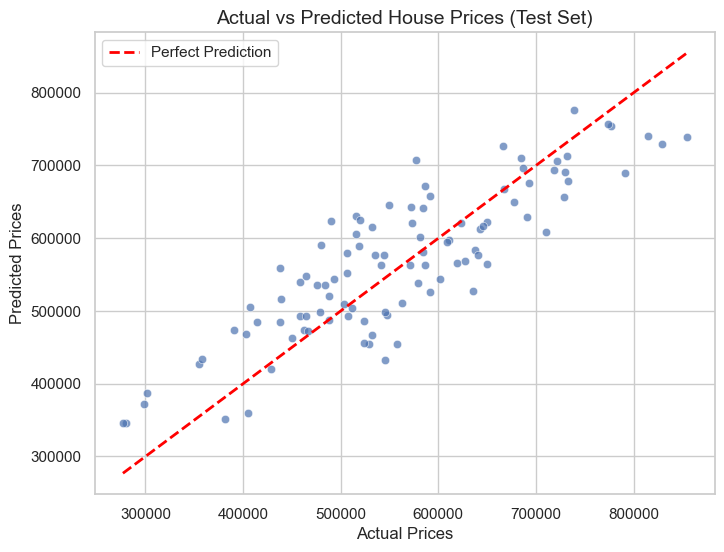

In [ ]:
# Task 3.4 Visualise the Predicted vs Actual Prices Create a scatter plot comparing the actual prices and predicted prices for the test set

import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a DataFrame for Actual vs Predicted prices for both models
results_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (MLR)': y_pred_lr
    })

# Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.7, color='b', edgecolor='w')

# Add the perfect prediction (diagonal) line
# Determine the min and max limits to fit the line
min_val = min(min(y_test), min(y_pred_lr))
max_val = max(max(y_test), max(y_pred_lr))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

# Format the plot
plt.title('Actual vs Predicted House Prices (Test Set)', fontsize=14)
plt.xlabel('Actual Prices', fontsize=12)
plt.ylabel('Predicted Prices', fontsize=12)
plt.legend()

# Display the plot
plt.show()


<mark></mark><mark>The scatter graph for actual and predicted prices using MLR shows that prices predicted are close to its actual price. This is because dots are close to the prediction line. Prices predicted for $500,000 to $600,000 have more spread than other prices because dots are evenly distributed above and below the prediction line.</mark>

In [ ]:
# Task 3.5 Evaluate the Model Evaluate the model using Root Mean Squared Error (RMSE) and interpret the results.

# Create a DataFrame for Actual vs Predicted prices for both models
results_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (MLR)': y_pred_lr
})

# Display the table
print(results_df) 

# Calculate RMSE for MLR
from sklearn.metrics import mean_squared_error
import numpy as np
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Root Mean Squared Error (RMSE) for MLR: {rmse_lr}")


     Actual Price  Predicted Price (MLR)
361   591058.7089          525669.926934
73    667693.0003          668141.051861
374   532377.5802          467168.904743
155   478489.2990          498375.548472
104   730197.4806          691359.973840
..            ...                    ...
347   464849.9178          493645.118779
86    572360.6499          643248.170875
75    557752.8374          454235.083741
438   649930.0523          564489.566281
15    523527.9747          456453.859955

[100 rows x 2 columns]
Root Mean Squared Error (RMSE) for MLR: 63952.37599755184


<mark>Interpretation: RMSE for 100 train (test) data using MLR is $66,868. The table shows that the predicted price at $667,786 (row 73) is more accurate as this price is almost equal to the actual price.</mark>

## Step 4: Compare with Random Forest Regressor

Task 4.1: Train a Random Forest Model
Train a Random Forest Regressor model and evaluate its performance.

Task 4.2: Visualise Actual vs Predicted Prices for Random Forest
Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.

Task 4.3: Model Comparison
Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?

In [ ]:
##Task 4.1: Train a Random Forest Model Train a Random Forest Regressor model and evaluate its performance.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Define independent variables and dependent variable 
X_rf = df_house_price[['Square_Feet','Num_Bedrooms','Num_Floors','Garage_Size','Location_Score','Distance_to_Center']]
y_rf = df_house_price['Price']

# Split the data into 80% training and 20% testing
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_rf, y_rf, test_size=0.2, random_state=42)


# Initialize the Random Forest model
model_rf = RandomForestRegressor(n_estimators=200, random_state=42)

# Fit the Random Forest model on the training data
model_rf.fit(X_train_rf, y_train_rf)

# Make predictions on the test data
y_pred_rf = model_rf.predict(X_test_rf)

🏃 View run calm_parcel_95qqhncy at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/6429dd04-6114-4209-a2ee-e3269af643c5/workloads/ML/ML/Automatic/workspaceid/0560cf16-634c-49f9-9bb1-cfcb75568715/#/experiments/7c80decb-3abe-4855-914d-26cbdfed85f2/runs/955f4866-fd91-4658-9708-55911c9bd822
🧪 View experiment at: https://pbipauseast5-australiaeast.pbidedicated.windows.net/webapi/capacities/6429dd04-6114-4209-a2ee-e3269af643c5/workloads/ML/ML/Automatic/workspaceid/0560cf16-634c-49f9-9bb1-cfcb75568715/#/experiments/7c80decb-3abe-4855-914d-26cbdfed85f2


In [ ]:
# Display a table with Actual vs Predicted values
from sklearn.metrics import mean_squared_error

results_rf = pd.DataFrame({'Actual Prices': y_test_rf, 'Predictioned Prices': y_pred_rf})
display(results_rf)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
mse_rf = mean_squared_error(y_test_rf, y_pred_rf)
r2_rf = r2_score(y_test_rf, y_pred_rf)

print("Random Forest Model Performance")
print("Mean Absolute Error:", mae_rf)
print("Mean Squared Error:", mse_rf)
print("R-squared:", r2_rf)

Random Forest Model Performance
Mean Absolute Error: 60626.394959735044
Mean Squared Error: 5303380999.749392
R-squared: 0.6474246097557816


<mark>The Random Forest Regressor achieved a Mean Absolute Error (MAE) of approximately $60,626, indicating that the model's predictions were, on average, around $60,000 different from the actual house prices. The Mean Squared Error (MSE) was 5.30 billion, which heavily penalises larger prediction errors and is mainly useful for comparing model performance. The model achieved an R² score of 0.647, meaning it explains approximately 65% of the variation in house prices. Overall, the model demonstrates a reasonable level of predictive accuracy, although there is still room for improvement. Including additional features such as property age, condition, or neighbourhood characteristics could potentially increase the model's predictive performance.</mark>

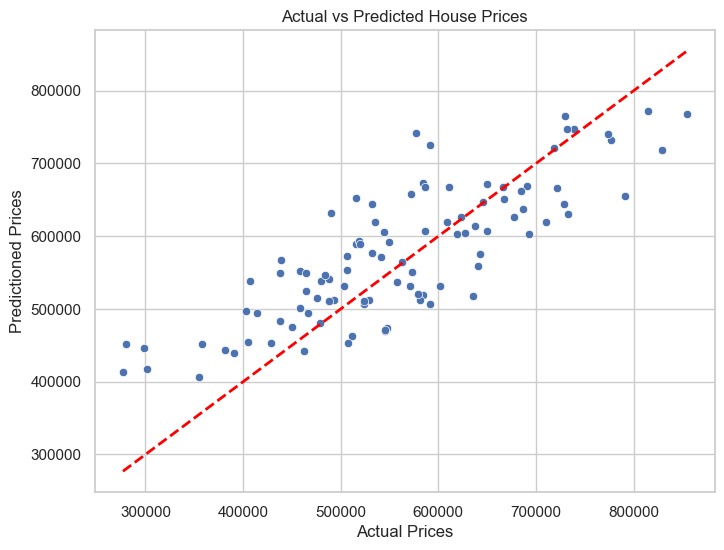

In [ ]:
##Task 4.2: Visualise Actual vs Predicted Prices for Random Forest Create a scatter plot comparing the actual prices and predicted prices for the Random Forest model.
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot between Trip Distance and Trip Price
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Actual Prices', y='Predictioned Prices', data=results_rf)

# Add perfect prediction line
min_val = min(min(y_test_rf), min(y_pred_rf))
max_val = max(max(y_test_rf), max(y_pred_rf))
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Perfect Prediction'
)


plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predictioned Prices')
plt.show()



<mark>The scatter plot compares the actual house prices with the prices predicted by the Random Forest model. The red dashed line represents perfect predictions, where the predicted price is equal to the actual price. Many of the data points lie reasonably close to this line, indicating that the model predicts house prices with a moderate level of accuracy. However, there is noticeable variation above and below the line, showing that the model both overestimates and underestimates some house prices. The model appears to overestimate some lower-priced properties and underestimate some higher-priced properties, suggesting that predictions become less accurate at the extremes of the price range. Overall, the Random Forest model captures the general relationship between the input features and house prices, while still leaving room for improvement. This interpretation is consistent with the model's R² score of 0.647, indicating that the model explains approximately 65% of the variation in house prices.</mark>


In [ ]:
##Task 4.3: Model Comparison Compare the RMSE values of both the MLR and Random Forest models. Which model performs better?
# Evaluate model performance
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))

print(f"Random Forest RMSE: {rmse_rf}")


Random Forest RMSE: 72824.3159923208


In [ ]:
# Create a DataFrame for Actual vs Predicted prices for both models
results_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price (MLR)': y_pred_lr,
    'Predicted Price (Random Forest)': y_pred_rf
})

# Display the table
print(results_df.head())  # Shows the first few rows of the table

     Actual Price  Predicted Price (MLR)  Predicted Price (Random Forest)
361   591058.7089          525669.926934                    506872.535394
73    667693.0003          668141.051861                    650935.222501
374   532377.5802          467168.904743                    577400.432425
155   478489.2990          498375.548472                    481112.620890
104   730197.4806          691359.973840                    765357.678848


In [ ]:
# Compare the RMSE of both models
print(f"RMSE for MLR: {rmse_lr}")
print(f"RMSE for Random Forest: {rmse_rf}")

# Provide insights
if rmse_lr < rmse_rf:
    print("The Multiple Linear Regression model performs better based on RMSE.")
else:
    print("The Random Forest model performs better based on RMSE.")

RMSE for MLR: 63952.37599755184
RMSE for Random Forest: 72824.3159923208
The Multiple Linear Regression model performs better based on RMSE.


<mark>The Root Mean Squared Error (RMSE) was used to compare the predictive performance of the Multiple Linear Regression (MLR) and Random Forest models. The MLR model achieved an RMSE of 63,952, while the Random Forest model produced a higher RMSE of 72,824. Since a lower RMSE indicates that the model's predictions are, on average, closer to the actual house prices, the MLR model performed better on this dataset. Although Random Forest is often capable of modelling more complex relationships, the results suggest that the relationship between the selected features and house prices may be sufficiently linear, allowing the simpler MLR model to achieve more accurate predictions.</mark>

## Step 5: Conclusion and Insights

Task 5.1: Insights and Recommendations

Based on the RMSE and visualisations, summarise which model performs better and why.

Discuss any improvements that could be made to both models.

<mark>The performance of the Multiple Linear Regression (MLR) and Random Forest models was evaluated using the Root Mean Squared Error (RMSE) and by comparing the actual and predicted house prices in the scatter plots. The MLR model achieved a lower RMSE of 63,952.38, compared with 72,824.32 for the Random Forest model. Since a lower RMSE indicates more accurate predictions, the MLR model performed better on this dataset.

<mark>The scatter plots also support this conclusion. Both models showed a positive relationship between the actual and predicted house prices, indicating that they were able to capture the overall trend in the data. However, both models showed some prediction errors, particularly for houses at the higher and lower ends of the price range. The Random Forest model displayed greater variation from the perfect prediction line, which is consistent with its higher RMSE value.</mark>

<mark>Based on these results, the Multiple Linear Regression model is recommended for predicting house prices using this dataset, as it produced more accurate predictions than the Random Forest model. Although Random Forest models are often effective at modelling complex relationships, the results suggest that the relationships within this dataset may be largely linear, allowing the simpler MLR model to perform better.</mark>

<mark>To improve the performance of both models, additional property features such as house age, property condition, neighbourhood characteristics, or nearby amenities could be included, as these factors may influence house prices but were not available in the current dataset. Further improvements could also be achieved by tuning the Random Forest model's parameters, such as the maximum tree depth or minimum number of samples required for each split, to determine whether its predictive accuracy can be improved.</mark></mark>


Thank you for your submission. Please put more effort into completing the mission requirements. In industry, data analysts are expected not only to create charts but also to explain the insights and findings derived from them. In your submission, the visualisations were provided, but there was no commentary or interpretation, which is not good analytical practice.

Please ensure that all requirements are addressed and that your work demonstrates both technical skills and critical thinking.
